# Kirill Burin - 923357830

In [1102]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("wildfires_sample_100k.csv")
print("This dataset has", df.shape[0], " of rows and", df.shape[1],"number of columns. And the name and data types of those columns is")
print(df.dtypes)


This dataset has 100000  of rows and 39 number of columns. And the name and data types of those columns is
OBJECTID                        int64
FOD_ID                          int64
FPA_ID                         object
SOURCE_SYSTEM_TYPE             object
SOURCE_SYSTEM                  object
NWCG_REPORTING_AGENCY          object
NWCG_REPORTING_UNIT_ID         object
NWCG_REPORTING_UNIT_NAME       object
SOURCE_REPORTING_UNIT          object
SOURCE_REPORTING_UNIT_NAME     object
LOCAL_FIRE_REPORT_ID           object
LOCAL_INCIDENT_ID              object
FIRE_CODE                      object
FIRE_NAME                      object
ICS_209_INCIDENT_NUMBER        object
ICS_209_NAME                   object
MTBS_ID                        object
MTBS_FIRE_NAME                 object
COMPLEX_NAME                   object
FIRE_YEAR                       int64
DISCOVERY_DATE                float64
DISCOVERY_DOY                   int64
DISCOVERY_TIME                float64
STAT_CAUSE_CODE    

/var/folders/0d/2h5lcz1509b998xc0dns7s900000gn/T/ipykernel_74442/3788660553.py:6: DtypeWarning: Columns (10,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("wildfires_sample_100k.csv")


In [1103]:
# COLUMN NAME: HOW MUCH VALUES IS MISSING
# IF not shows here then no values are missing from that column
for i in df:
    if df[i].isna().sum() != 0:
        print(i , df[i].isna().sum())

LOCAL_FIRE_REPORT_ID 77654
LOCAL_INCIDENT_ID 43621
FIRE_CODE 82817
FIRE_NAME 51229
ICS_209_INCIDENT_NUMBER 98634
ICS_209_NAME 98634
MTBS_ID 99423
MTBS_FIRE_NAME 99423
COMPLEX_NAME 99751
DISCOVERY_TIME 46972
CONT_DATE 47483
CONT_DOY 47483
CONT_TIME 51813
COUNTY 35991
FIPS_CODE 35991
FIPS_NAME 35991


#### My first impression is that this dataset has a lot of missing values in several columns. Some columns also have messy types, because they are marked as object even when they look “numeric” at first. For example, LOCAL_INCIDENT_ID is mixed, since some rows look like numbers with leading zeros and other rows are codes like NY-123-USA, so it should be treated like an ID string, not a real number column. That is a data-quality concern because it can break math operations and can confuse cleaning if you assume it is numeric. I also checked for common fake-missing text like "N/A" or "Missing", and it looks like most missing values are just real nan, so isna() can detect them correctly. Variables that is datatype if objects are Mixed values

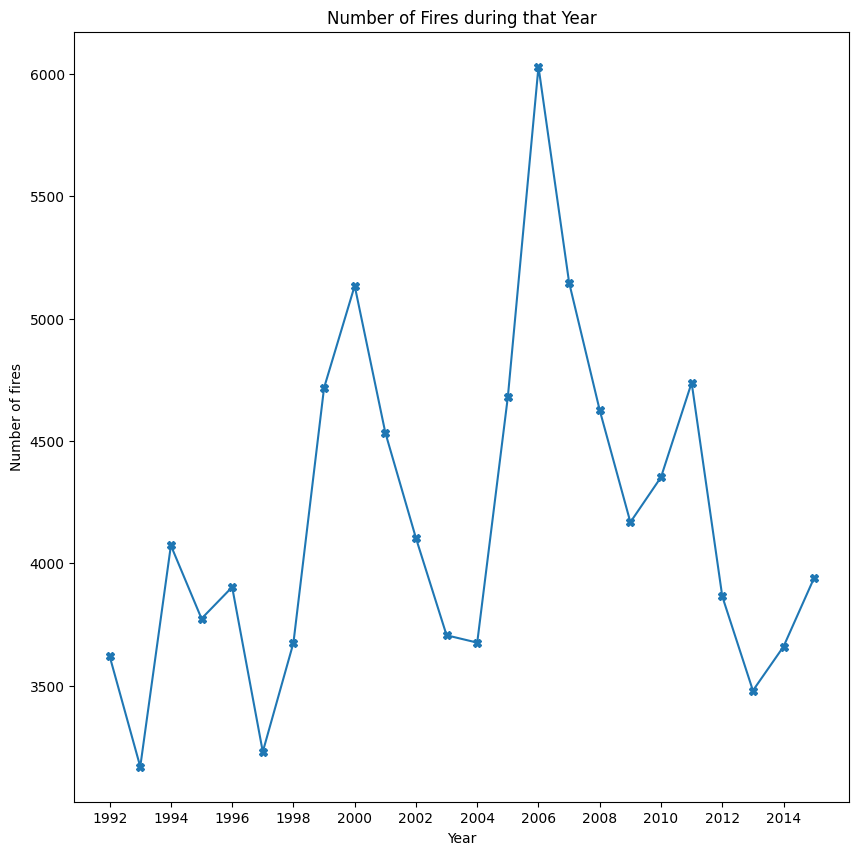

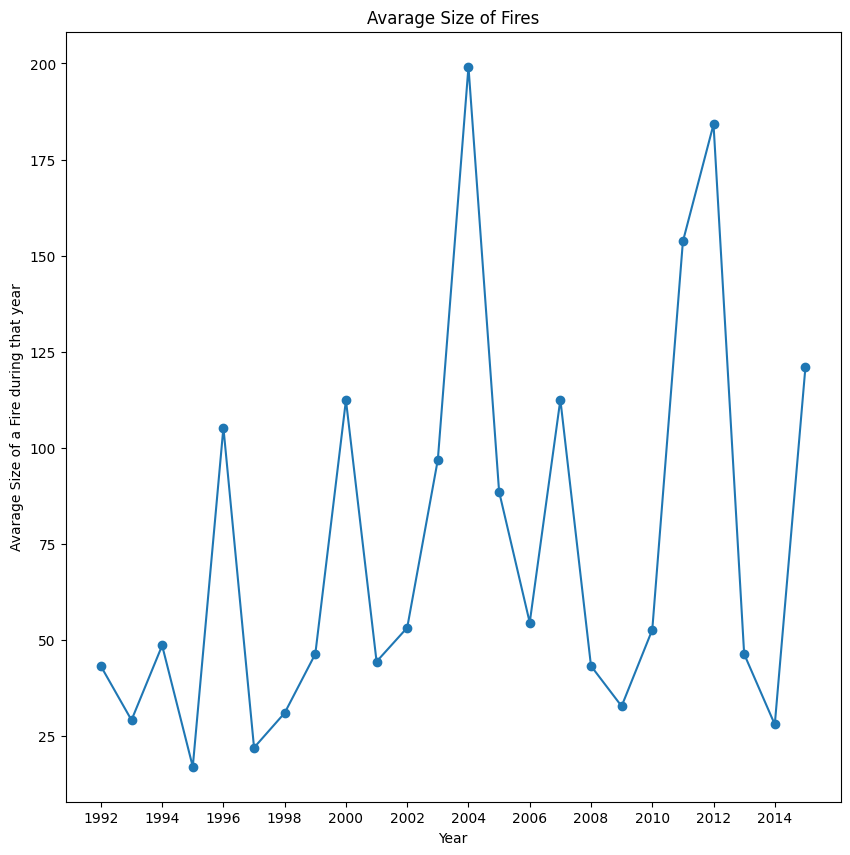

In [1104]:
df["DISCOVERY_DOY"] = df["DISCOVERY_DOY"].astype("string").str.zfill(3)
df["FIRE_DATE"] = df["FIRE_YEAR"].astype("string") + df["DISCOVERY_DOY"]

df["FIRE_DATE"] = pd.to_datetime(df["FIRE_DATE"],format = "%Y%j")

x = df["FIRE_YEAR"].value_counts().sort_index(ascending=True)
plt.figure(figsize = (10,10))
plt.plot(x, marker = "X")
plt.xticks(range(1992, 2015,2))
plt.xlabel("Year")
plt.ylabel("Number of fires")
plt.title("Number of Fires during that Year")
plt.show()

y = df.groupby("FIRE_YEAR")["FIRE_SIZE"].mean()
plt.figure(figsize = (10,10))
plt.plot(y, marker = "o")
plt.xticks(range(1992, 2015,2))
plt.xlabel("Year")
plt.ylabel("Avarage Size of a Fire during that year")
plt.title("Avarage Size of Fires")
plt.show()


#### In 2012, the number of fires was only moderate, but the average size of the fire was very large. There is a similar trend in 2015, where the number of fires was not very high, but the average size of the fire was moderately large. The maximum number of fires occurred in 2006 (or 2007, depending on how you are reading it), but the average size of the fire in 2006 was only moderate compared to 2004, which had the second-largest average size of fire.

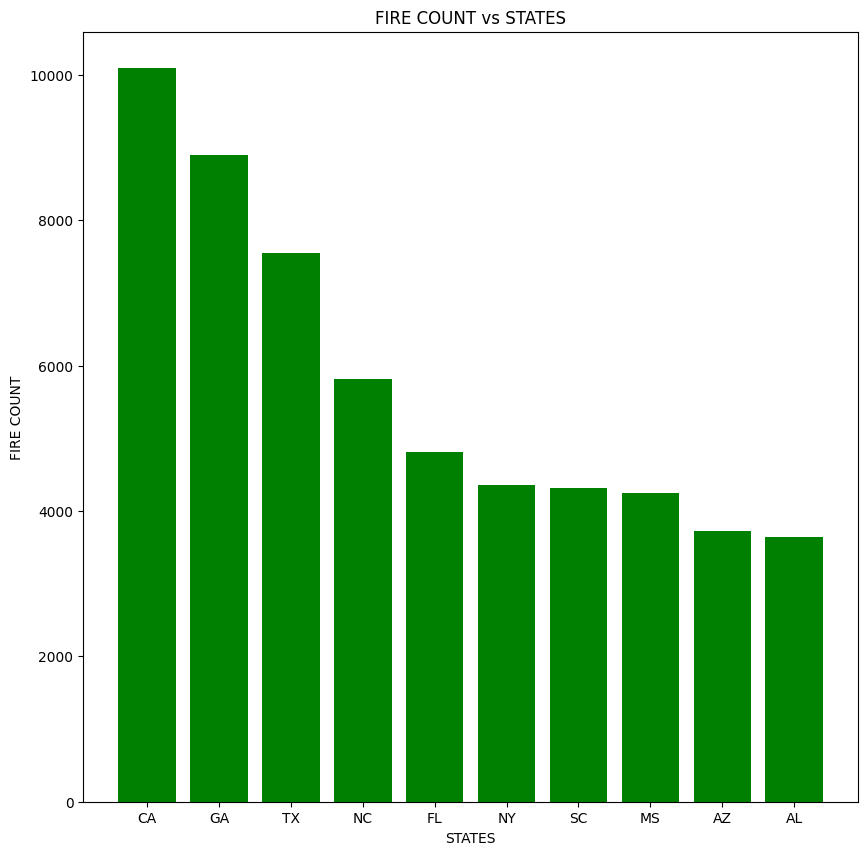

In [1105]:
x = df["STATE"].value_counts()
top_10_states = x.iloc[:10]
plt.figure(figsize=(10,10))
plt.bar(x = top_10_states.index, height = top_10_states.values, color = "Green")
plt.xlabel("STATES")
plt.ylabel("FIRE COUNT")
plt.title("FIRE COUNT vs STATES")
plt.show()

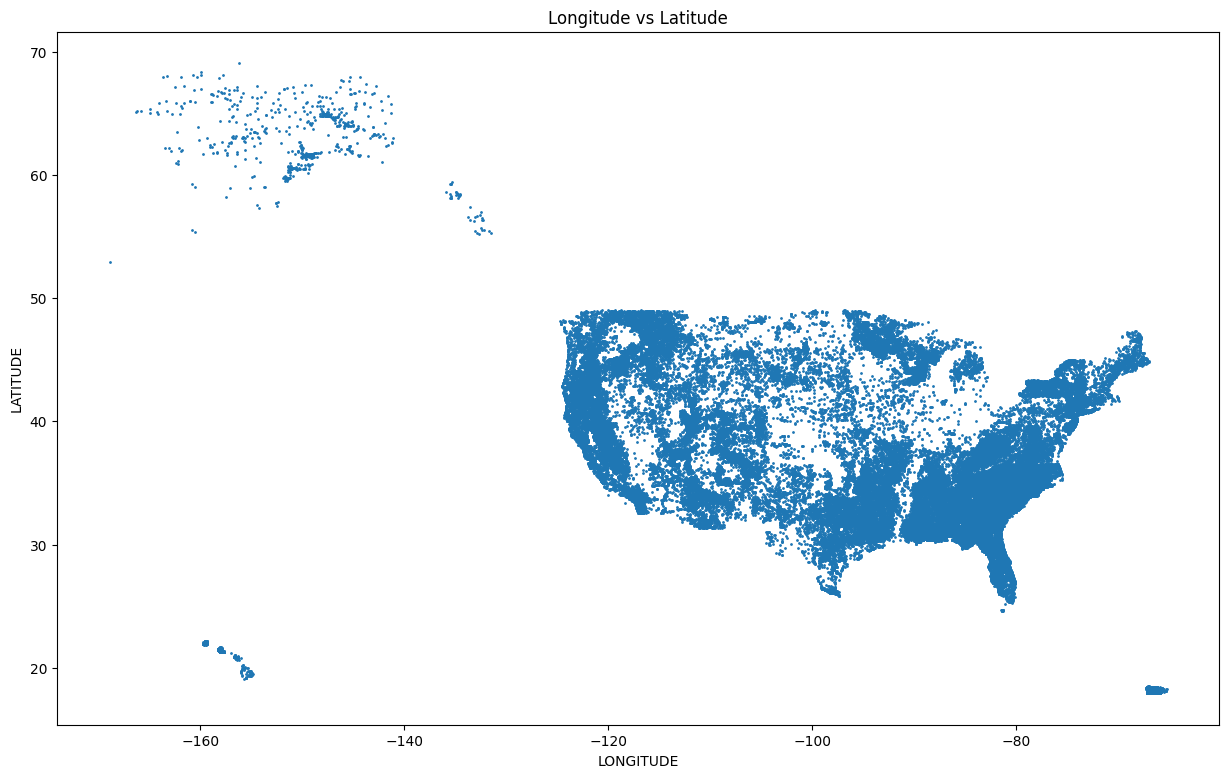

In [1106]:
plt.figure(figsize=(15,9))
plt.scatter(df["LONGITUDE"],df["LATITUDE"],s=1)
plt.xlabel("LONGITUDE")
plt.ylabel("LATITUDE")
plt.title("Longitude vs Latitude")
plt.show()

#### The majority of the ignition points are located in the contiguous U.S., and the dots clearly define the shape of the country. The highest concentration of points is in the Southeastern part of the country and in some regions of the West. There are also scattered points in the interior. The state of Alaska is visible as a distinct cluster in the northwest corner of the country at higher latitudes. The state of Hawaii is visible as a distinct cluster away from the mainland.

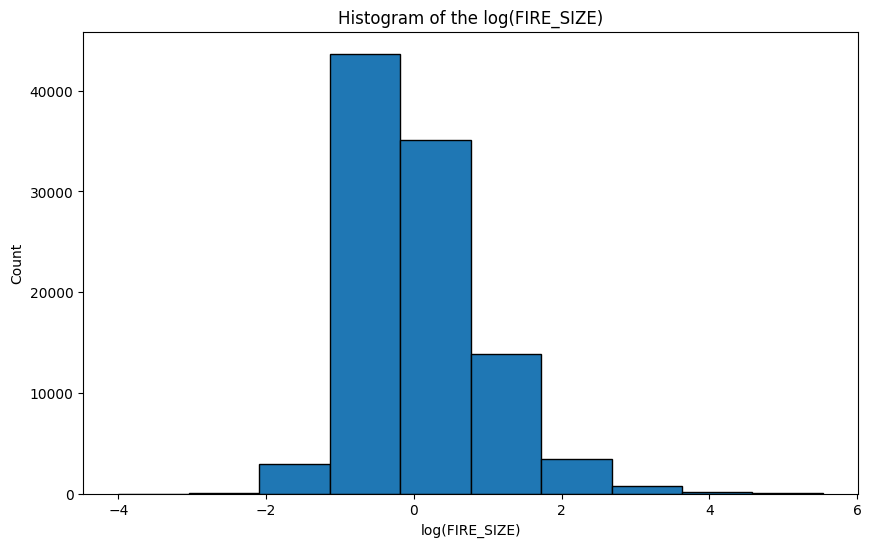

/var/folders/0d/2h5lcz1509b998xc0dns7s900000gn/T/ipykernel_74442/3045110368.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels = labels1)


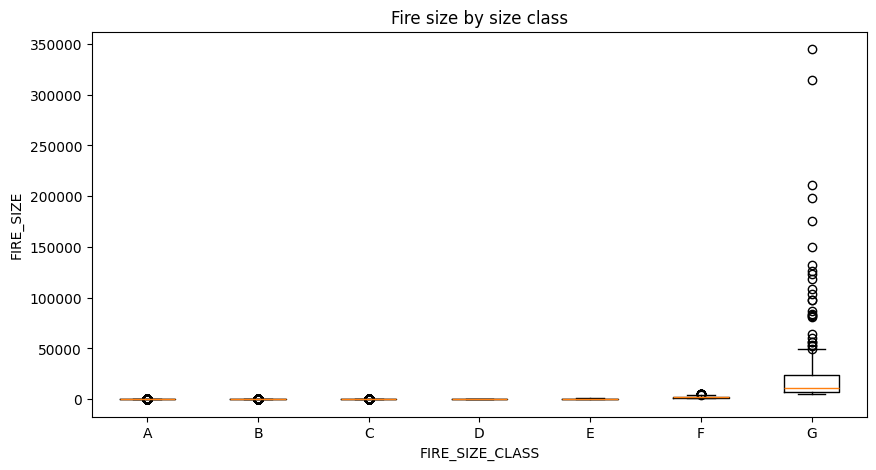

count    100000.000000
mean         74.870143
std        2385.856452
min           0.000100
25%           0.100000
50%           1.000000
75%           3.400000
90%          17.000000
99%         480.000000
max      344833.000000
Name: FIRE_SIZE, dtype: float64

In [1107]:
z  = np.log10(df["FIRE_SIZE"].values)
plt.figure(figsize = (10,6))
plt.hist(z, edgecolor = "Black", linewidth = 1)
plt.xlabel("log(FIRE_SIZE)")
plt.ylabel("Count")
plt.title("Histogram of the log(FIRE_SIZE)")
plt.show()


data = []
labels1 = ["A","B","C","D","E","F","G"]
for i in labels1:
    data.append(df.loc[df["FIRE_SIZE_CLASS"]==i,"FIRE_SIZE"])


plt.figure(figsize=(10, 5))
plt.boxplot(data, labels = labels1)
plt.xlabel("FIRE_SIZE_CLASS")
plt.ylabel("FIRE_SIZE")
plt.title("Fire size by size class")
plt.show()


df["FIRE_SIZE"].describe(percentiles =[0.25, 0.50, 0.75, 0.90, 0.99])

#### Fires are mostly small, which is clear from the median (1.0), 75% (3.4), and even 90% (17), but there is a long tail with a few very large fires (99% is 480 and max is 344,833).Because of the presence of such extreme values, the mean (74.9) gets pulled up and does not give a “typical” fire.In prediction, this means that it would be difficult to predict FIRE_SIZE, and it is always better to predict log(FIRE_SIZE) or size class, and use methods that are robust to outliers and imbalance.

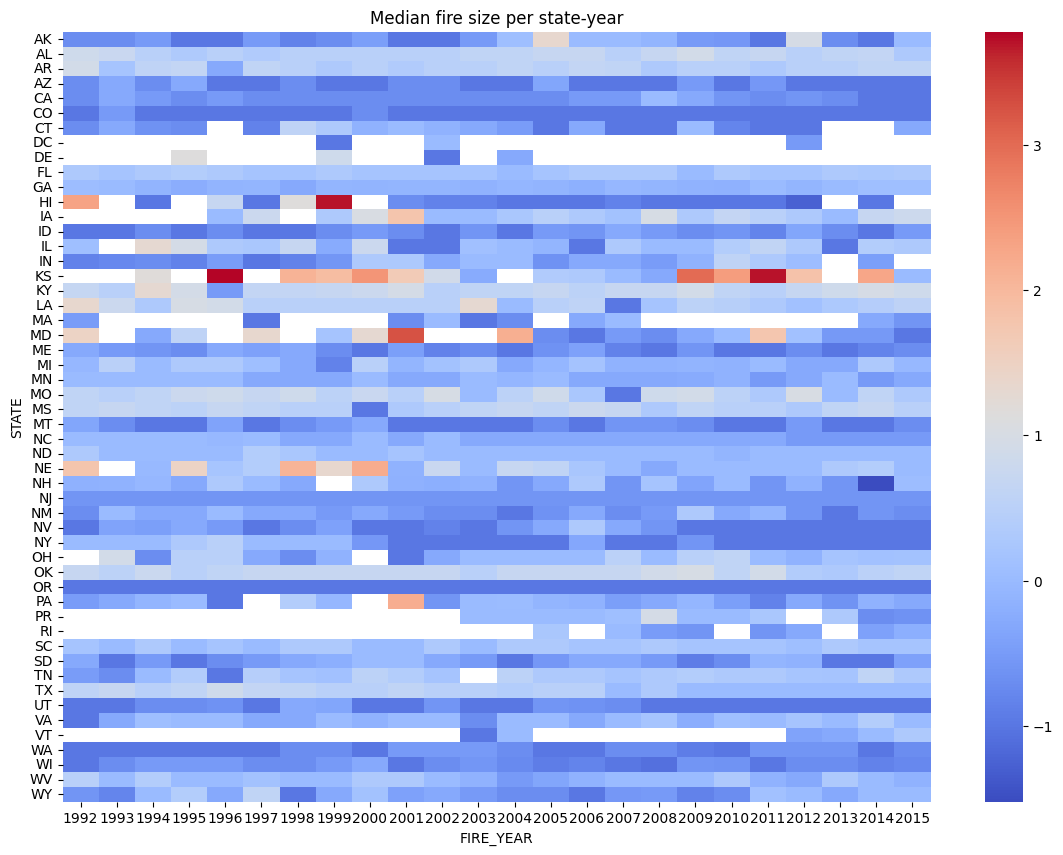

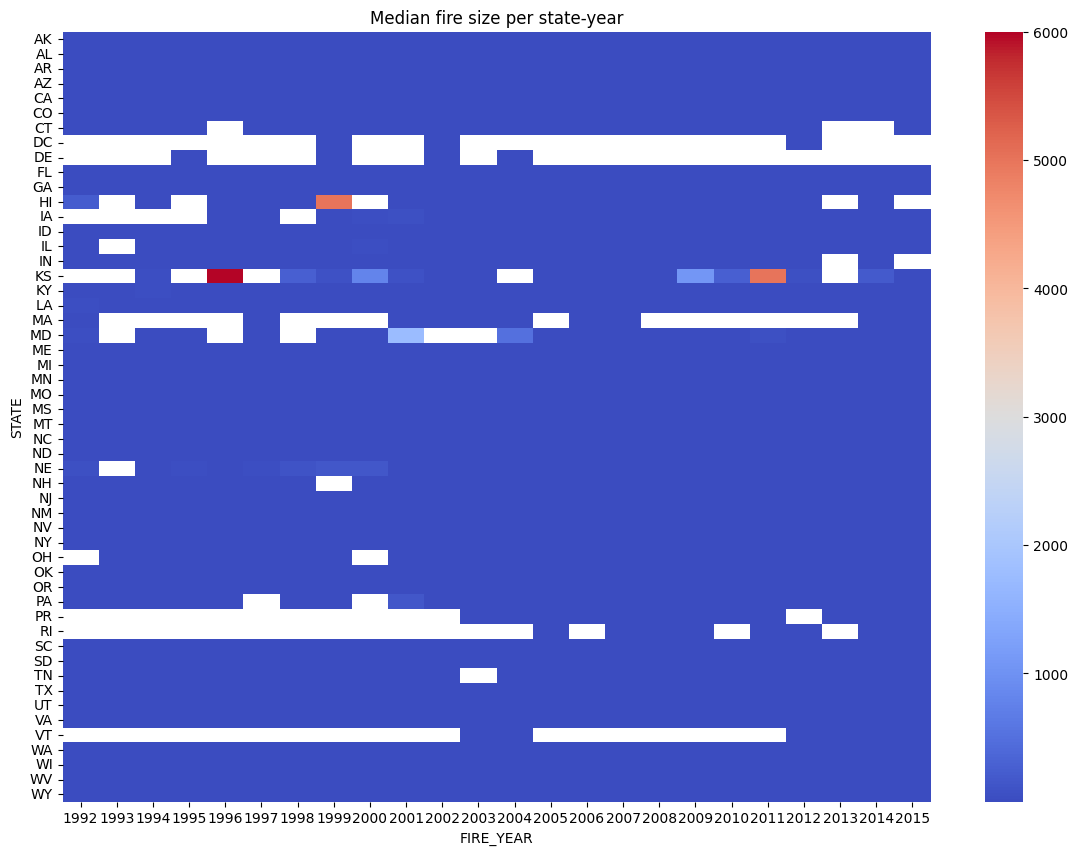

In [1108]:
df["LOG_FIRE_SIZE"] = np.log10(df["FIRE_SIZE"])
data1 = df.pivot_table(index = "STATE", columns="FIRE_YEAR", values="LOG_FIRE_SIZE", aggfunc="median")
plt.figure(figsize=(14,10))
sns.heatmap(data1, annot=False, cmap="coolwarm")
plt.xlabel("FIRE_YEAR")
plt.ylabel("STATE")
plt.title("Median fire size per state-year")
plt.show()

data2 = df.pivot_table(index = "STATE", columns="FIRE_YEAR", values="FIRE_SIZE", aggfunc="median")
plt.figure(figsize=(14,10))
sns.heatmap(data2, annot=False, cmap="coolwarm")
plt.xlabel("FIRE_YEAR")
plt.ylabel("STATE")
plt.title("Median fire size per state-year")
plt.show()


#### Most of the data points are dark blue, so the median size of fires is usually small for most states and years.Some states have “spikes” of light data points in particular years, which means that in those years, the median size of fires in that state was much larger than usual.There is no obvious trend of increase or decrease over time for the country as a whole, since the large changes seem to be localized to particular states and years.The white areas probably indicate that there is no data (or no fires) for that state-year, so those years cannot be compared for those states.

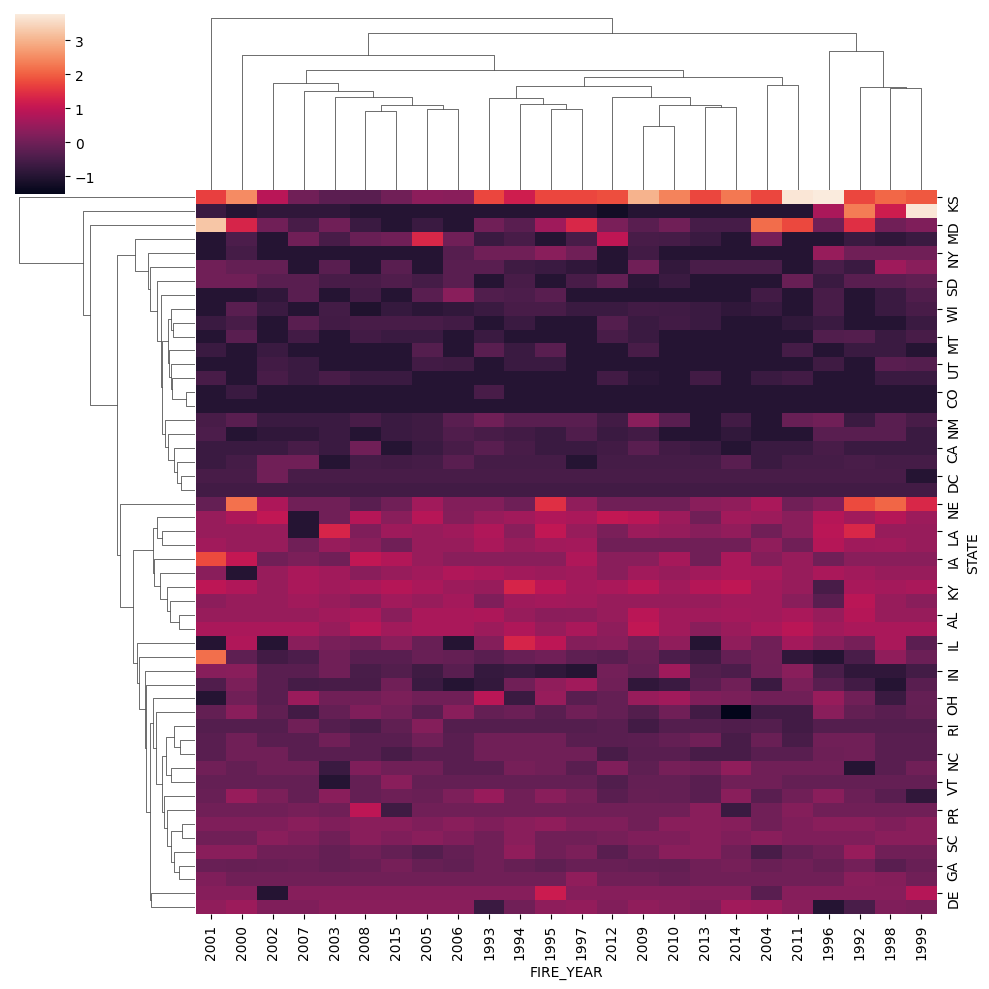

In [1109]:
data3 = df.pivot_table(index = "STATE", columns="FIRE_YEAR", values="LOG_FIRE_SIZE", aggfunc="median")
data3_filled = data3.apply(lambda h: h.fillna(h.median()), axis=1)
sns.clustermap(data3_filled)


#### I chose to create a clustered heatmap because it enables me to analyze the data in a way that goes beyond just viewing it. Rather than arranging the states alphabetically, the clustering process groups states based on similar patterns of wildfires over time. This enables me to view patterns and recognize groups of states that have experienced larger fires in similar years. During the process of creating the pivot table, I realized that there were missing values for some state and year combinations. This occurred because some states did not have any recorded fires in particular years. To address this problem and prevent gaps in the data, I replaced the missing values with the median fire size for each state. This maintains the data realistic and prevents me from being skewed by extreme values.
